In [44]:
# ============================================
# 0) Setup
# ============================================
%pip install numpy

import os, glob, random
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Optional but nice
import seaborn as sns
sns.set_context("talk")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Ready.")

Note: you may need to restart the kernel to use updated packages.
Ready.


In [47]:
# ============================================
# 1) Point to your dataset root (Kaggle)
# ============================================
# In Kaggle, your dataset is usually mounted under:
# /kaggle/input/<your-dataset-name>/
#
# Set this to the folder that contains data.yaml, train/, valid/, test/
DATA_ROOT = Path("/home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8")  # <-- CHANGE THIS
YAML_PATH = DATA_ROOT / "data.yaml"

assert YAML_PATH.exists(), f"Could not find data.yaml at: {YAML_PATH}"
print("DATA_ROOT:", DATA_ROOT)
print("YAML_PATH:", YAML_PATH)

DATA_ROOT: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8
YAML_PATH: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8/data.yaml


In [48]:
# ============================================
# 2) Read YAML metadata
# ============================================
with open(YAML_PATH, "r") as f:
    data_cfg = yaml.safe_load(f)

train_rel = data_cfg["train"]
val_rel   = data_cfg["val"]
test_rel  = data_cfg["test"]

names = data_cfg["names"]
nc = data_cfg["nc"]

print("nc:", nc)
print("names:", names)
print("train:", train_rel)
print("val:", val_rel)
print("test:", test_rel)

nc: 8
names: ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table']
train: ../train/images
val: ../valid/images
test: ../test/images


In [49]:
# ============================================
# 3) Resolve split paths + helper functions
# ============================================
def resolve_images_dir(split_rel_path: str) -> Path:
    # data.yaml often uses paths like ../train/images (Roboflow export style)
    # We'll resolve relative to the YAML file location.
    p = (YAML_PATH.parent / split_rel_path).resolve()
    return p

train_images_dir = resolve_images_dir(train_rel)
val_images_dir   = resolve_images_dir(val_rel)
test_images_dir  = resolve_images_dir(test_rel)

print("train_images_dir:", train_images_dir)
print("val_images_dir:", val_images_dir)
print("test_images_dir:", test_images_dir)

def images_in_dir(images_dir: Path):
    exts = ["*.jpg","*.jpeg","*.png","*.bmp","*.webp"]
    files = []
    for e in exts:
        files.extend(glob.glob(str(images_dir / e)))
    return sorted(files)

def labels_dir_from_images_dir(images_dir: Path) -> Path:
    # Roboflow/YOLO typical structure: train/images + train/labels
    return images_dir.parent / "labels"

def label_path_for_image(image_path: Path, labels_dir: Path) -> Path:
    return labels_dir / (image_path.stem + ".txt")

train_images_dir: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/train/images
val_images_dir: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/valid/images
test_images_dir: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/test/images


In [50]:
# ============================================
# 4) Robust split detection + build dataframe
#    (Kaggle-safe version)
# ============================================

from pathlib import Path
import glob

def find_images_dir(root: Path, split_name: str):
    """
    Find split/images folder anywhere under DATA_ROOT.
    Handles both 'valid' and 'val'.
    """
    candidates = []
    for p in root.rglob("*"):
        if p.is_dir():
            parts = [x.lower() for x in p.parts]
            if split_name.lower() in parts and "images" in parts:
                candidates.append(p)
    return candidates[0] if candidates else None

# Auto-detect split folders
train_images_dir = find_images_dir(DATA_ROOT, "train")
val_images_dir   = find_images_dir(DATA_ROOT, "valid") or find_images_dir(DATA_ROOT, "val")
test_images_dir  = find_images_dir(DATA_ROOT, "test")

print("Detected paths:")
print(" train_images_dir:", train_images_dir)
print(" val_images_dir:  ", val_images_dir)
print(" test_images_dir: ", test_images_dir)

assert train_images_dir is not None, "Could not find train/images"
assert val_images_dir is not None, "Could not find valid/images or val/images"
assert test_images_dir is not None, "Could not find test/images"


def images_in_dir(images_dir: Path):
    exts = ["*.jpg","*.jpeg","*.png","*.bmp","*.webp"]
    files = []
    for e in exts:
        files.extend(glob.glob(str(images_dir / e)))
    return sorted(files)


def labels_dir_from_images_dir(images_dir: Path):
    return images_dir.parent / "labels"


def label_path_for_image(image_path: Path, labels_dir: Path):
    return labels_dir / (image_path.stem + ".txt")


def parse_yolo_label_file(label_file: Path):
    boxes = []
    if not label_file.exists():
        return boxes
    txt = label_file.read_text().strip()
    if not txt:
        return boxes
    for line in txt.splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        x, y, w, h = map(float, parts[1:5])
        boxes.append((cls, x, y, w, h))
    return boxes


def build_annotations_df(split_name: str, images_dir: Path):
    img_files = [Path(p) for p in images_in_dir(images_dir)]
    labels_dir = labels_dir_from_images_dir(images_dir)

    rows = []
    img_rows = []

    for img_path in img_files:
        lp = label_path_for_image(img_path, labels_dir)
        boxes = parse_yolo_label_file(lp)

        img_rows.append({
            "split": split_name,
            "image_path": str(img_path),
            "label_path": str(lp),
            "n_objects": len(boxes),
        })

        for (cls, x, y, w, h) in boxes:
            rows.append({
                "split": split_name,
                "image_path": str(img_path),
                "class_id": cls,
                "class_name": names[cls] if cls < len(names) else str(cls),
                "x_center": x,
                "y_center": y,
                "w": w,
                "h": h,
                "area": w*h,
                "aspect_ratio": (w/h) if h > 0 else None
            })

    return pd.DataFrame(rows), pd.DataFrame(img_rows)


# Build dataframes
ann_train, imgs_train = build_annotations_df("train", train_images_dir)
ann_val, imgs_val     = build_annotations_df("val",   val_images_dir)
ann_test, imgs_test   = build_annotations_df("test",  test_images_dir)

ann = pd.concat([ann_train, ann_val, ann_test], ignore_index=True)
imgs = pd.concat([imgs_train, imgs_val, imgs_test], ignore_index=True)

print("Images:", len(imgs))
print("Annotations (boxes):", len(ann))
ann.head()

Detected paths:
 train_images_dir: /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8/train/images
 val_images_dir:   /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8/valid/images
 test_images_dir:  /home/ltgwgeorge/Desktop/Business/ML/ML-auto-wheels/Hospital.v1-hospitaldata.yolov8/test/images
Images: 1457
Annotations (boxes): 2411


,split,image_path,class_id,class_name,x_center,y_center,w,h,area,aspect_ratio
0,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,5,sofa,0.482812,0.588281,0.904687,0.517188,0.467893,1.749245
1,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,5,sofa,0.500000,0.596875,0.995313,0.510938,0.508542,1.948012
2,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,6,stool,0.489660,0.488160,0.777090,0.700770,0.544561,1.108909
3,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,0,Monitor,0.504687,0.486719,0.920312,0.725000,0.667227,1.269397
4,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,4,chair,0.473040,0.475600,0.572760,0.903600,0.517546,0.633865


In [51]:
# ============================================
# 5) Add image metadata (width, height, brightness, contrast)
#    (This loops through images once; OK for ~1.5k images on Kaggle CPU)
# ============================================
def image_stats(image_path: str):
    im = cv2.imread(image_path)
    if im is None:
        return None
    h, w = im.shape[:2]
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    mean_brightness = float(gray.mean())
    contrast = float(gray.std())
    # channel means in RGB order for human sanity
    b, g, r = cv2.split(im)
    return {
        "img_w": int(w),
        "img_h": int(h),
        "img_aspect": float(w / h) if h else np.nan,
        "brightness": mean_brightness,
        "contrast": contrast,
        "mean_r": float(r.mean()),
        "mean_g": float(g.mean()),
        "mean_b": float(b.mean()),
    }

img_meta = []
for p in imgs["image_path"].tolist():
    st = image_stats(p)
    if st is None:
        st = {"img_w": np.nan, "img_h": np.nan, "img_aspect": np.nan,
              "brightness": np.nan, "contrast": np.nan,
              "mean_r": np.nan, "mean_g": np.nan, "mean_b": np.nan}
    st["image_path"] = p
    img_meta.append(st)

img_meta = pd.DataFrame(img_meta)
imgs = imgs.merge(img_meta, on="image_path", how="left")

# Attach width/height to each annotation row too
ann = ann.merge(imgs[["image_path","img_w","img_h"]], on="image_path", how="left")

# Pixel coordinates for boxes (useful for some viz)
ann["x_center_px"] = ann["x_center"] * ann["img_w"]
ann["y_center_px"] = ann["y_center"] * ann["img_h"]
ann["w_px"] = ann["w"] * ann["img_w"]
ann["h_px"] = ann["h"] * ann["img_h"]
ann["area_px"] = ann["w_px"] * ann["h_px"]

print("Done.")
imgs.head()

Done.


,split,image_path,label_path,n_objects,img_w,img_h,img_aspect,brightness,contrast,mean_r,mean_g,mean_b
0,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,1,640,640,1.0,146.043845,66.713875,153.102825,144.307493,136.042039
1,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,1,640,640,1.0,90.858928,52.199079,91.877578,91.674221,84.130908
2,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,1,1000,1000,1.0,229.130689,61.807685,229.759488,228.918549,228.275137
3,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,1,640,640,1.0,181.906741,64.096758,174.504648,183.105916,194.934307
4,train,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,/home/ltgwgeorge/Desktop/Business/ML/ML-auto-w...,1,500,500,1.0,211.083488,81.322127,211.083488,211.083488,211.083488


In [52]:
def show_title(title):
    plt.title(title, pad=12, fontweight="bold")

def fig_ok(figsize=(10,6)):
    plt.figure(figsize=figsize)
    plt.grid(True, alpha=0.2)

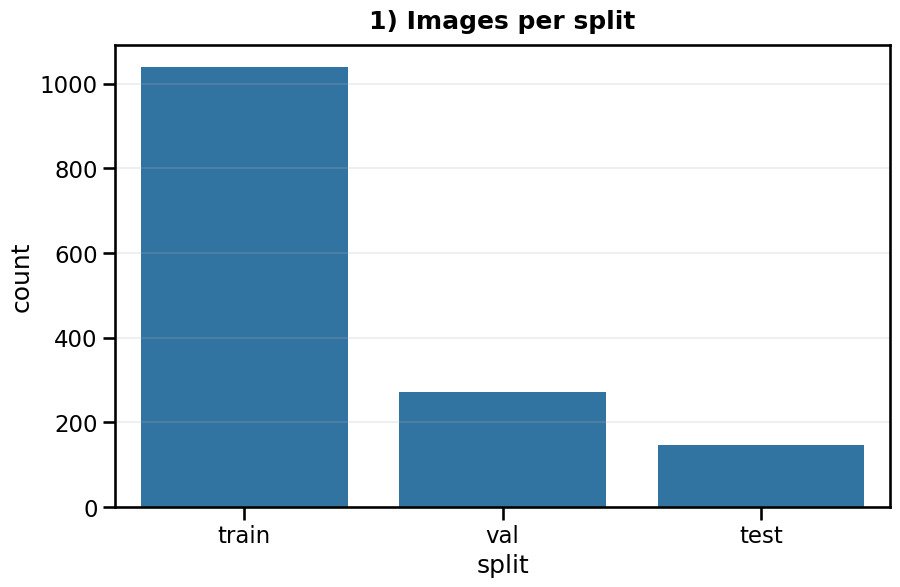

In [53]:
fig_ok()
sns.countplot(data=imgs, x="split")
show_title("1) Images per split")
plt.show()

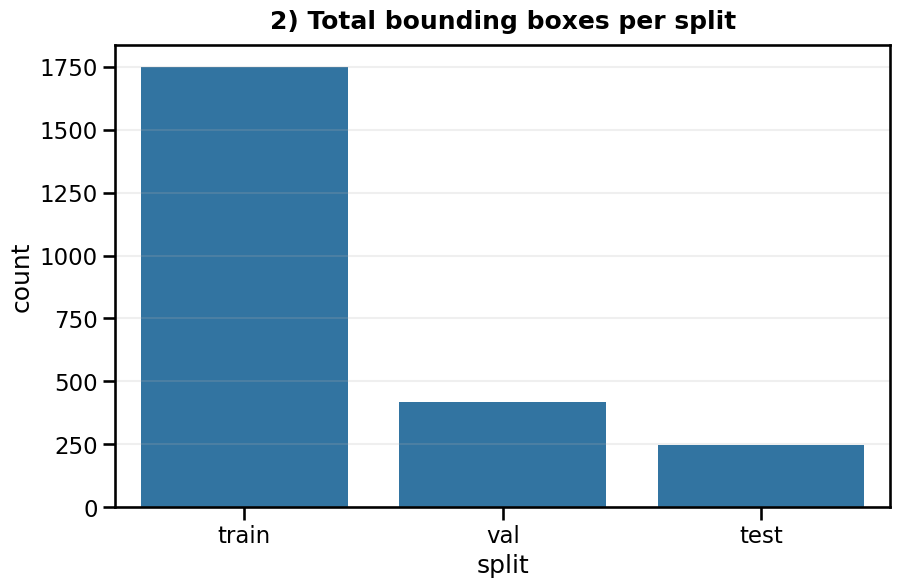

In [54]:
fig_ok()
sns.countplot(data=ann, x="split")
show_title("2) Total bounding boxes per split")
plt.show()

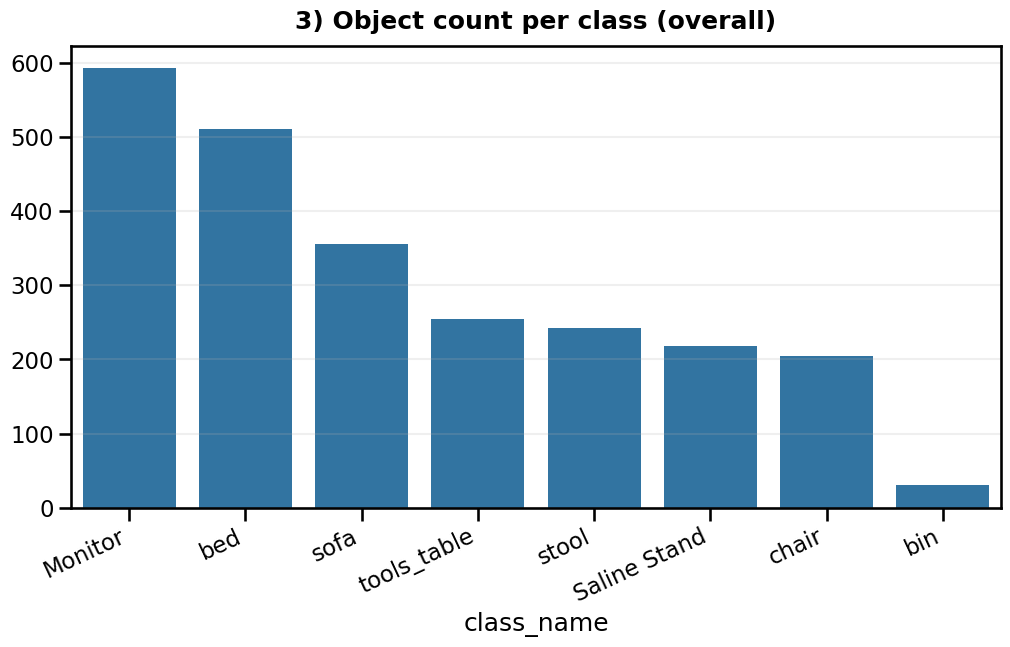

In [55]:
fig_ok((12,6))
class_counts = ann["class_name"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=25, ha="right")
show_title("3) Object count per class (overall)")
plt.show()

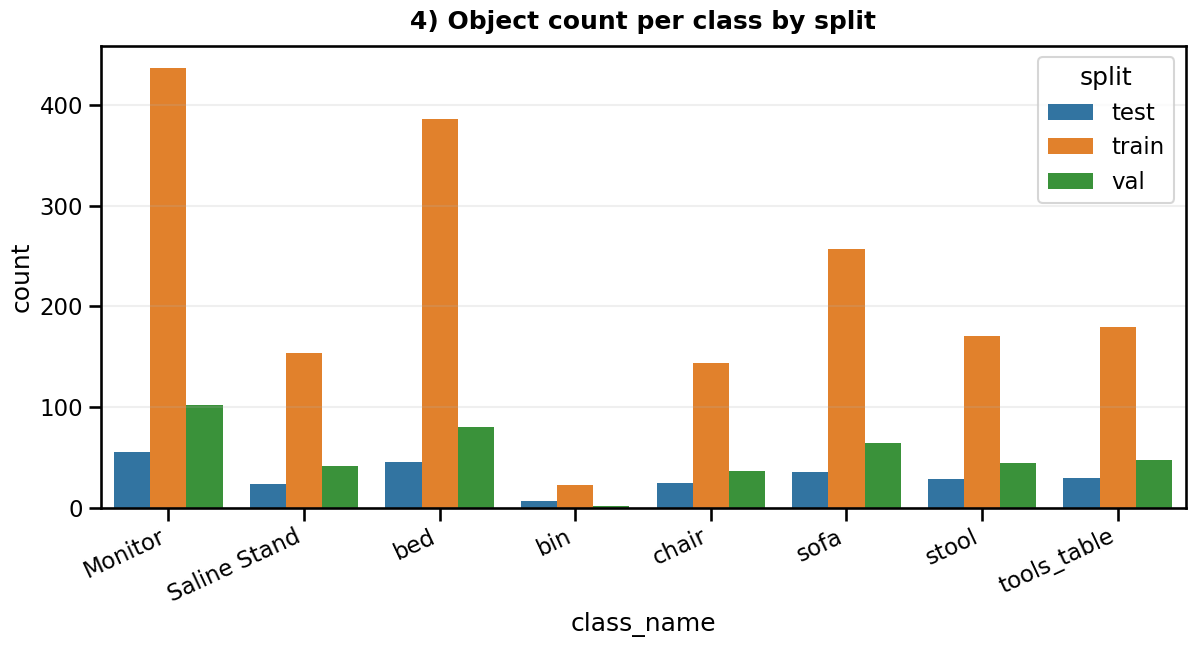

In [56]:
fig_ok((14,6))
tmp = ann.groupby(["split","class_name"]).size().reset_index(name="count")
sns.barplot(data=tmp, x="class_name", y="count", hue="split")
plt.xticks(rotation=25, ha="right")
show_title("4) Object count per class by split")
plt.show()

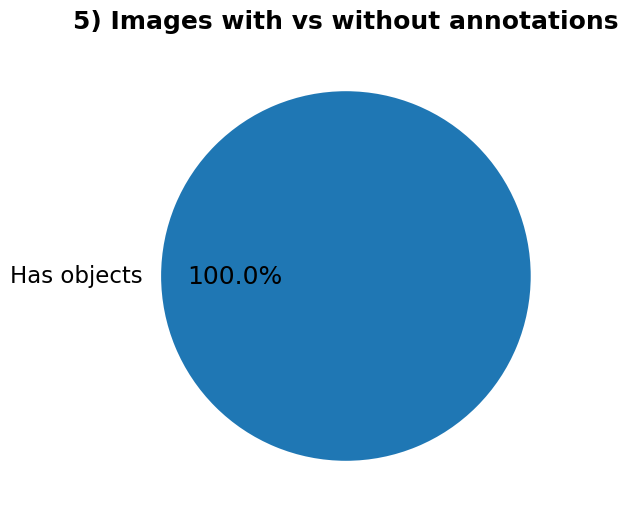

In [57]:
fig_ok()
imgs["has_objects"] = imgs["n_objects"] > 0
counts = imgs["has_objects"].value_counts().rename(index={True:"Has objects", False:"No objects"})
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
show_title("5) Images with vs without annotations")
plt.show()

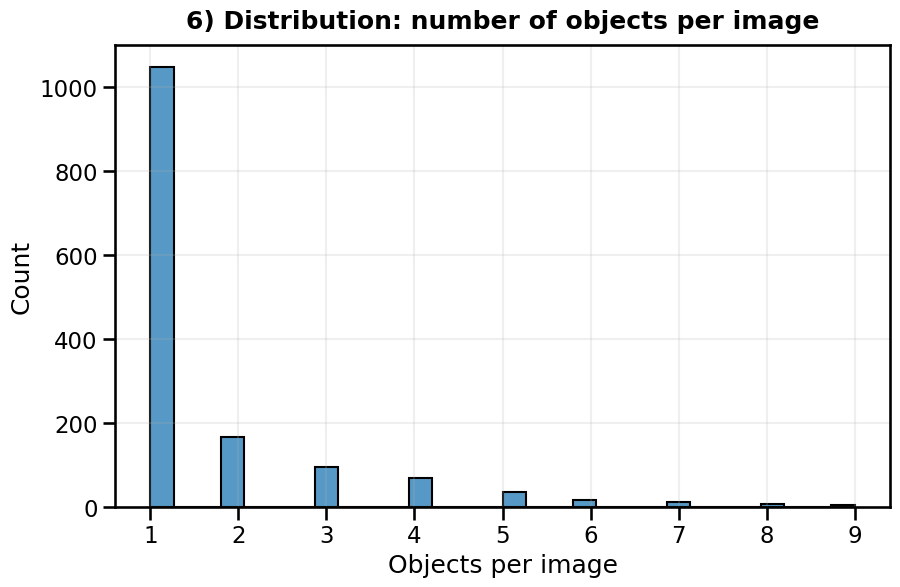

In [58]:
fig_ok()
sns.histplot(imgs["n_objects"], bins=30)
show_title("6) Distribution: number of objects per image")
plt.xlabel("Objects per image")
plt.show()

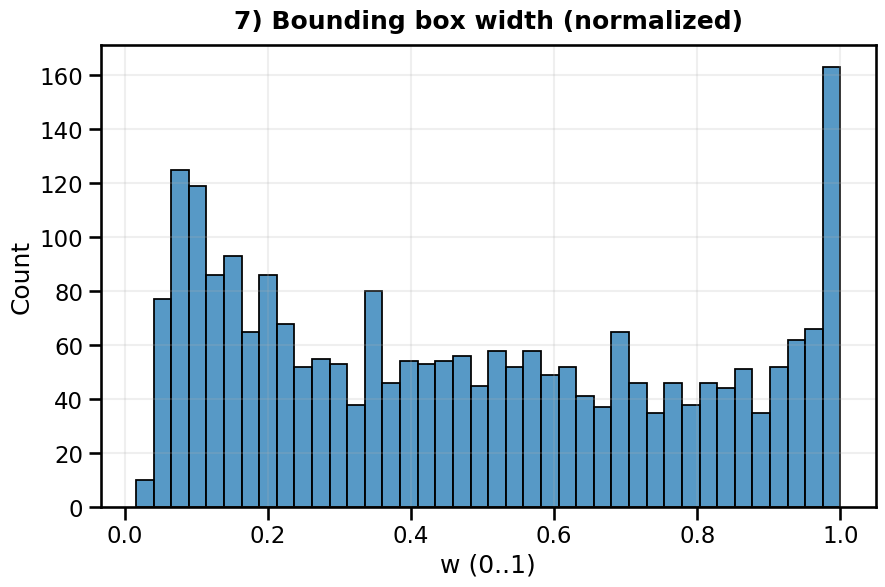

In [59]:
fig_ok()
sns.histplot(ann["w"], bins=40)
show_title("7) Bounding box width (normalized)")
plt.xlabel("w (0..1)")
plt.show()

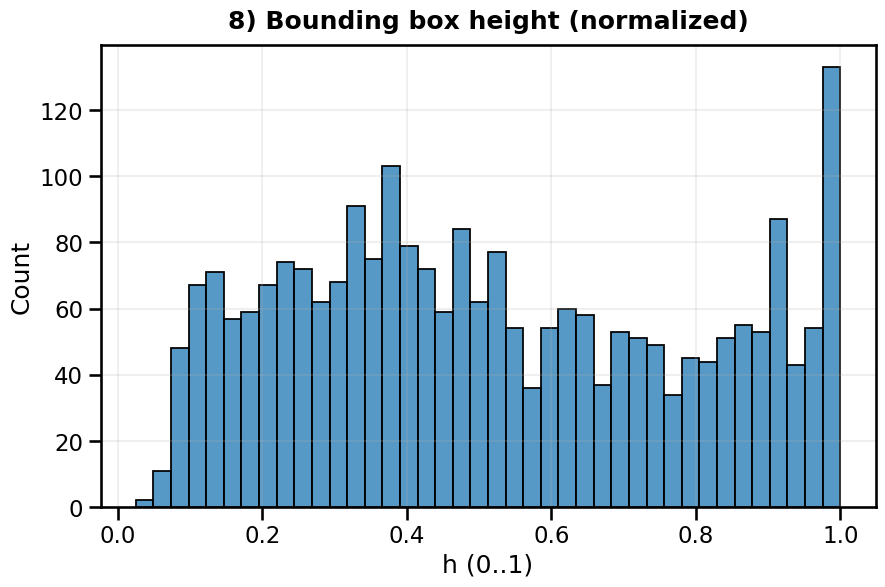

In [60]:
fig_ok()
sns.histplot(ann["h"], bins=40)
show_title("8) Bounding box height (normalized)")
plt.xlabel("h (0..1)")
plt.show()

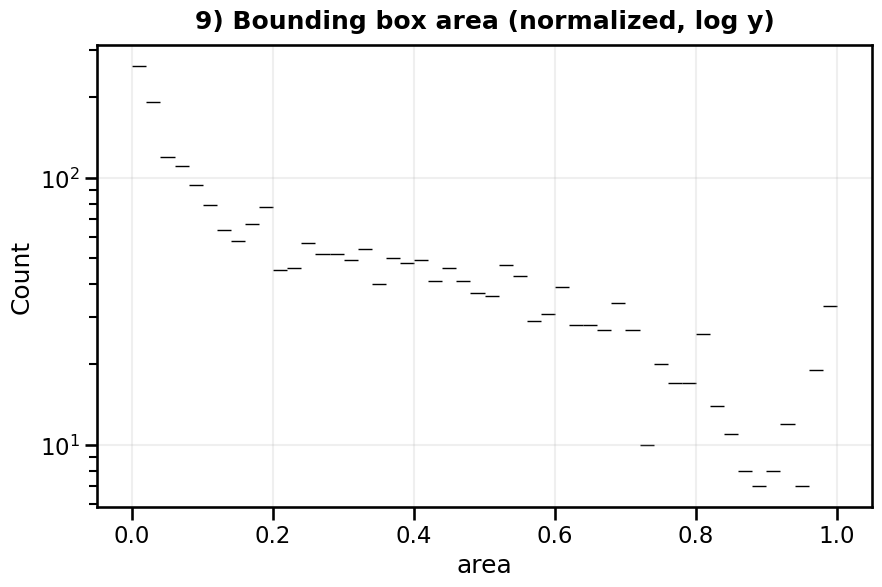

In [61]:
fig_ok()
sns.histplot(ann["area"], bins=50, log_scale=(False, True))
show_title("9) Bounding box area (normalized, log y)")
plt.xlabel("area")
plt.show()

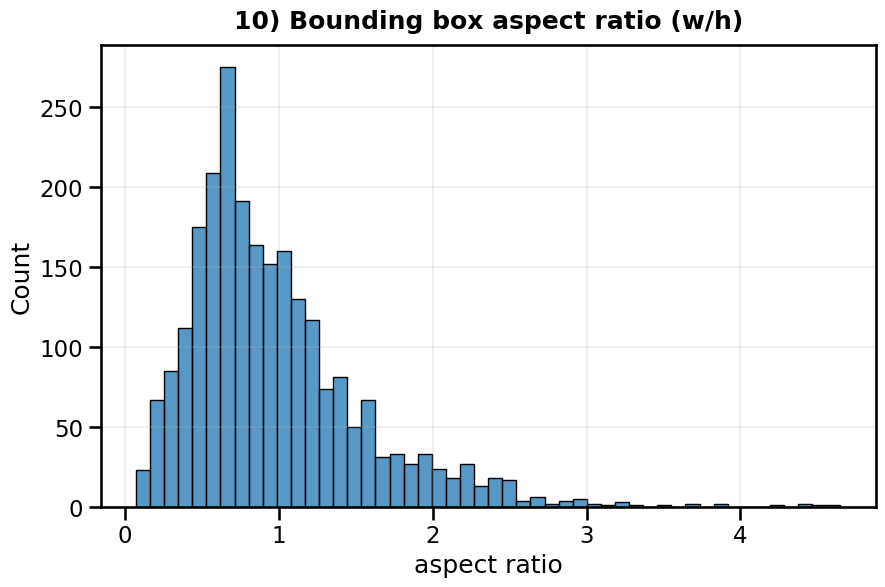

In [62]:
fig_ok()
sns.histplot(ann["aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna(), bins=50)
show_title("10) Bounding box aspect ratio (w/h)")
plt.xlabel("aspect ratio")
plt.show()

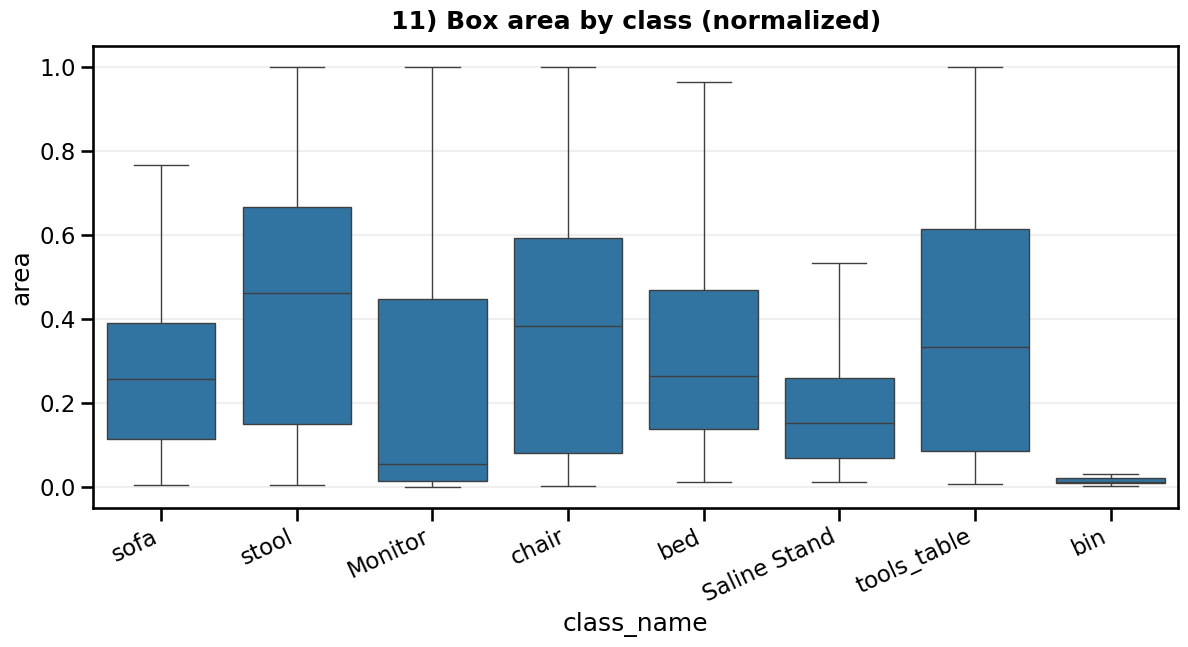

In [63]:
fig_ok((14,6))
sns.boxplot(data=ann, x="class_name", y="area", showfliers=False)
plt.xticks(rotation=25, ha="right")
show_title("11) Box area by class (normalized)")
plt.show()

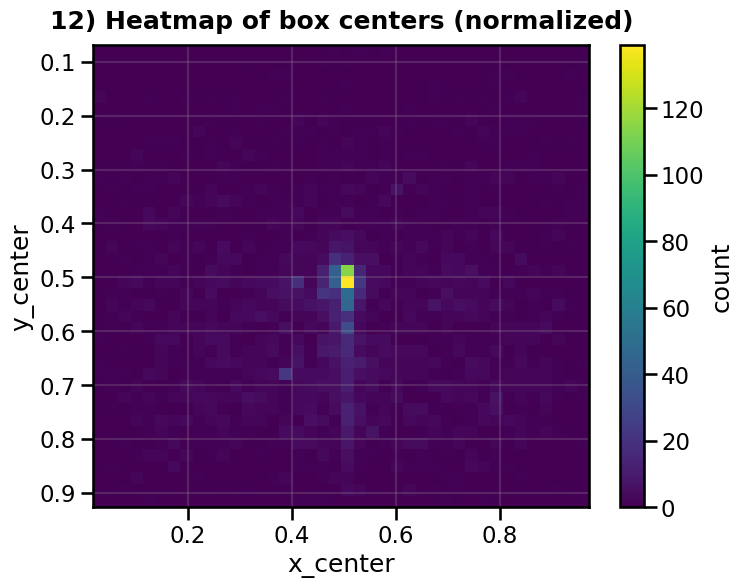

In [64]:
fig_ok((8,6))
plt.hist2d(ann["x_center"], ann["y_center"], bins=40)
plt.colorbar(label="count")
plt.gca().invert_yaxis()
show_title("12) Heatmap of box centers (normalized)")
plt.xlabel("x_center"); plt.ylabel("y_center")
plt.show()

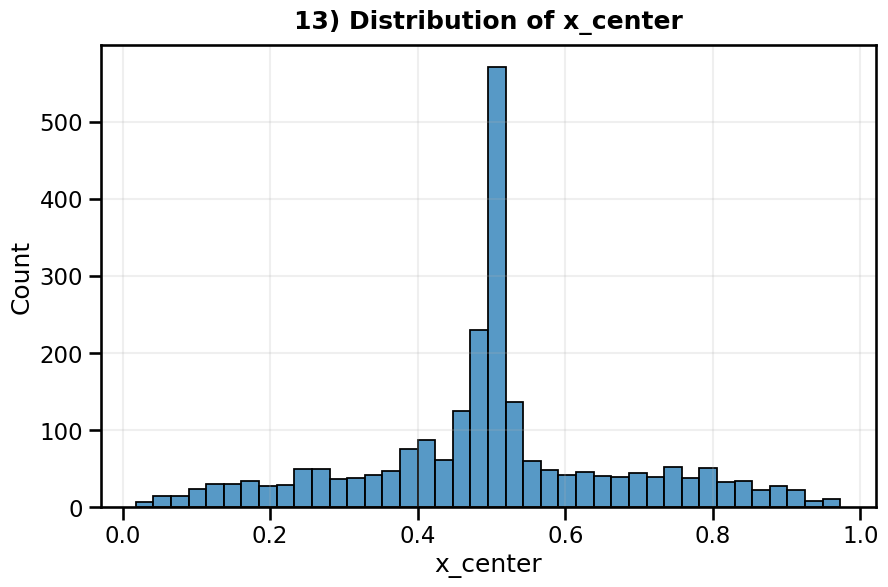

In [65]:
fig_ok()
sns.histplot(ann["x_center"], bins=40)
show_title("13) Distribution of x_center")
plt.show()

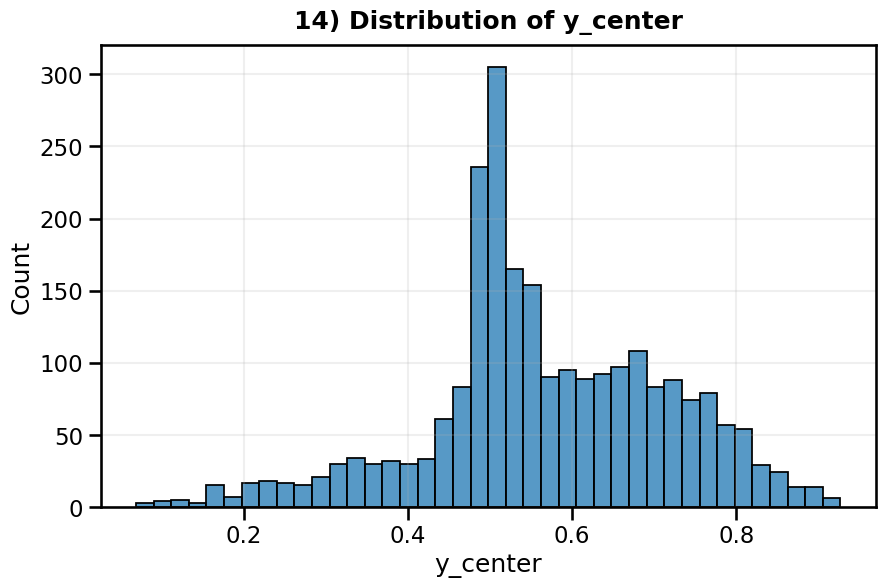

In [66]:
fig_ok()
sns.histplot(ann["y_center"], bins=40)
show_title("14) Distribution of y_center")
plt.show()

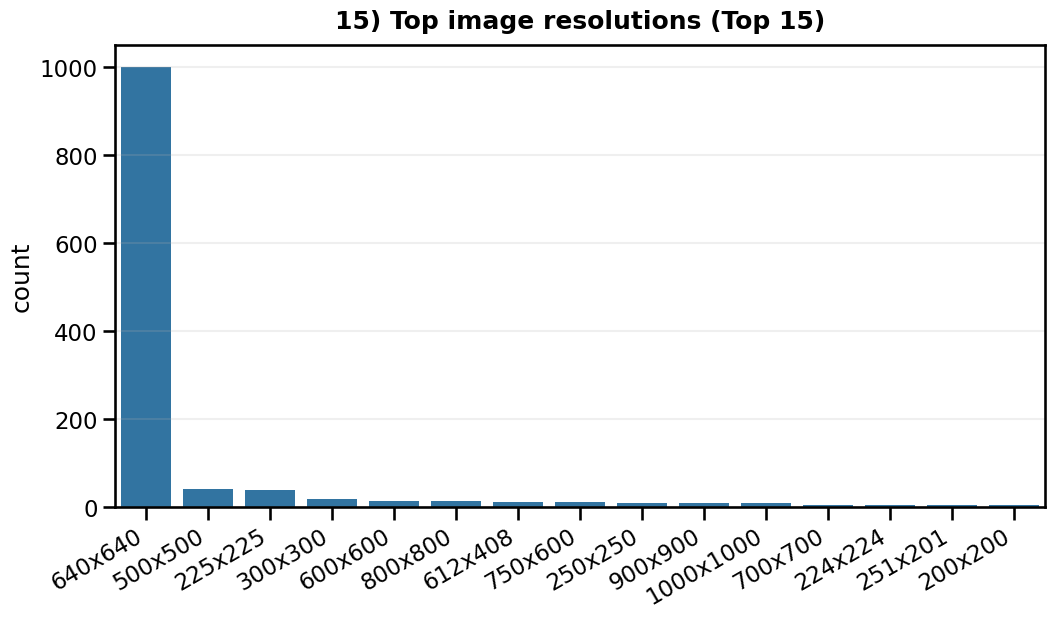

In [67]:
fig_ok((12,6))
res_counts = imgs.groupby(["img_w","img_h"]).size().sort_values(ascending=False).head(15)
labels = [f"{w}x{h}" for (w,h) in res_counts.index]
sns.barplot(x=labels, y=res_counts.values)
plt.xticks(rotation=30, ha="right")
show_title("15) Top image resolutions (Top 15)")
plt.ylabel("count")
plt.show()

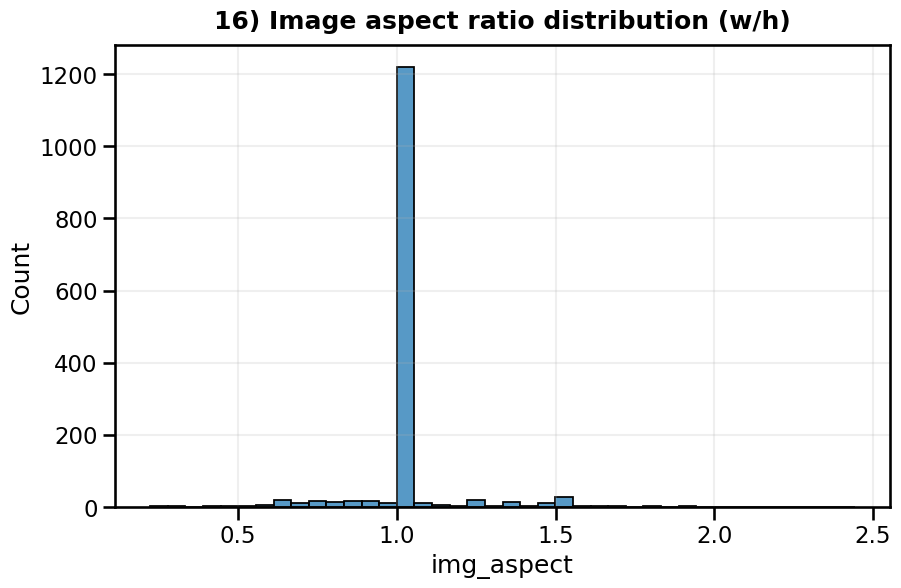

In [68]:
fig_ok()
sns.histplot(imgs["img_aspect"].dropna(), bins=40)
show_title("16) Image aspect ratio distribution (w/h)")
plt.show()

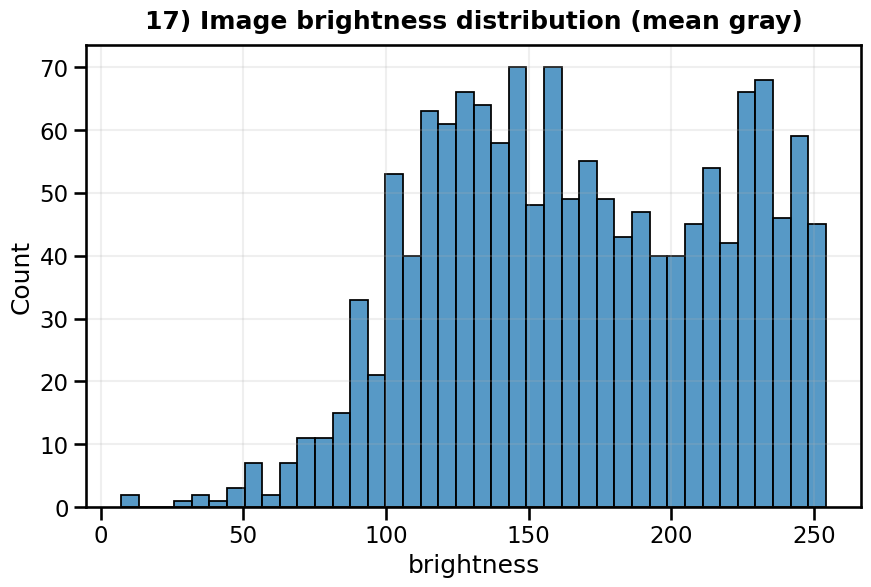

In [69]:
fig_ok()
sns.histplot(imgs["brightness"].dropna(), bins=40)
show_title("17) Image brightness distribution (mean gray)")
plt.show()

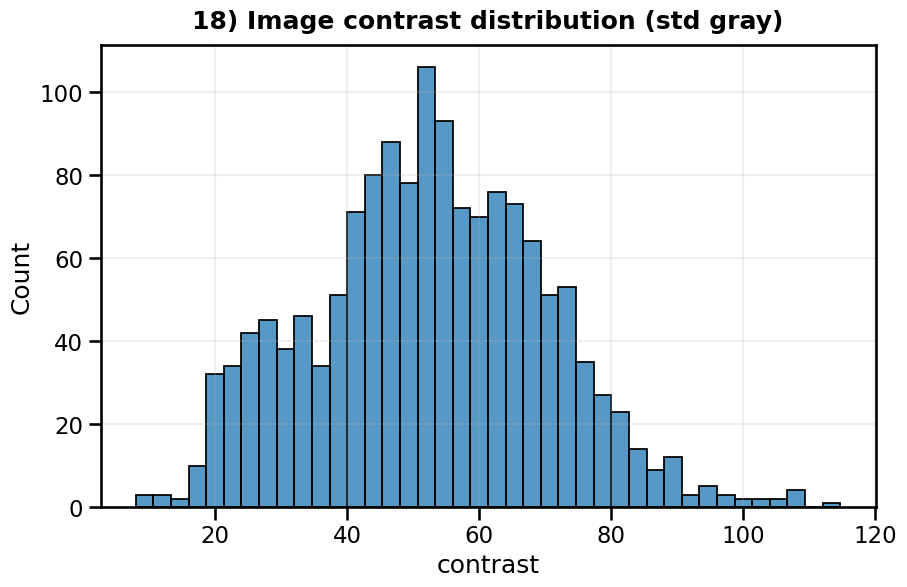

In [70]:
fig_ok()
sns.histplot(imgs["contrast"].dropna(), bins=40)
show_title("18) Image contrast distribution (std gray)")
plt.show()

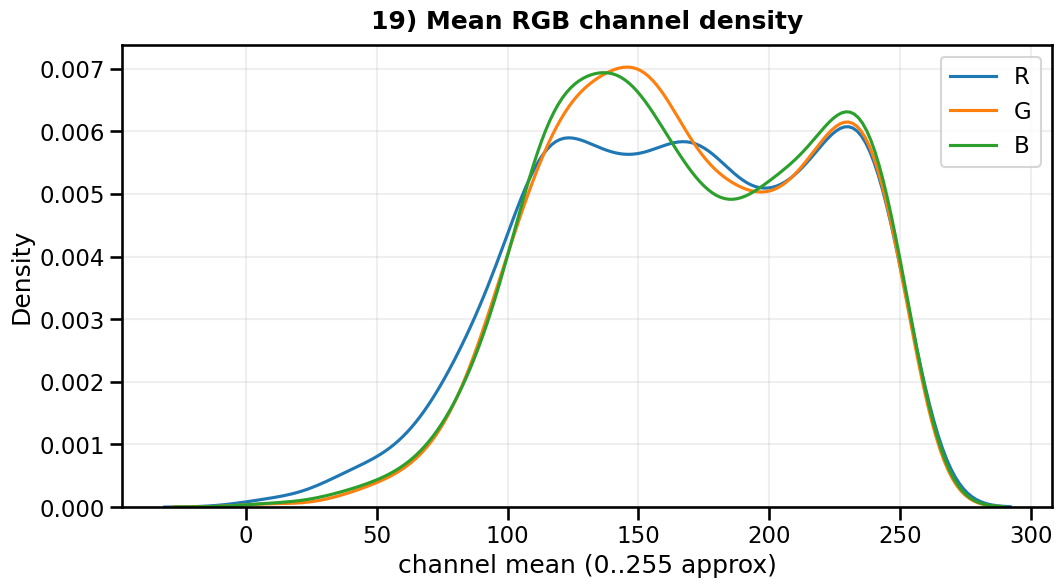

In [71]:
fig_ok((12,6))
sns.kdeplot(imgs["mean_r"].dropna(), label="R")
sns.kdeplot(imgs["mean_g"].dropna(), label="G")
sns.kdeplot(imgs["mean_b"].dropna(), label="B")
show_title("19) Mean RGB channel density")
plt.xlabel("channel mean (0..255 approx)")
plt.legend()
plt.show()

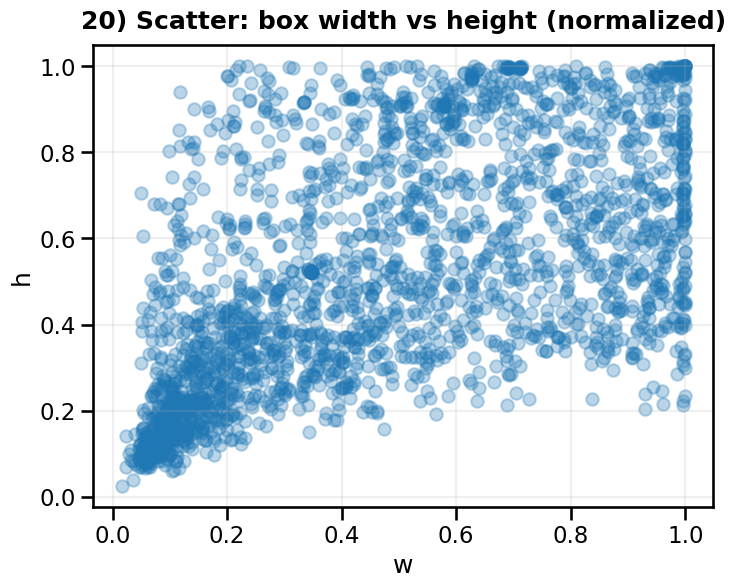

In [72]:
fig_ok((8,6))
sample = ann.sample(min(len(ann), 5000), random_state=RANDOM_SEED)  # keep plot light
plt.scatter(sample["w"], sample["h"], alpha=0.3)
show_title("20) Scatter: box width vs height (normalized)")
plt.xlabel("w"); plt.ylabel("h")
plt.show()

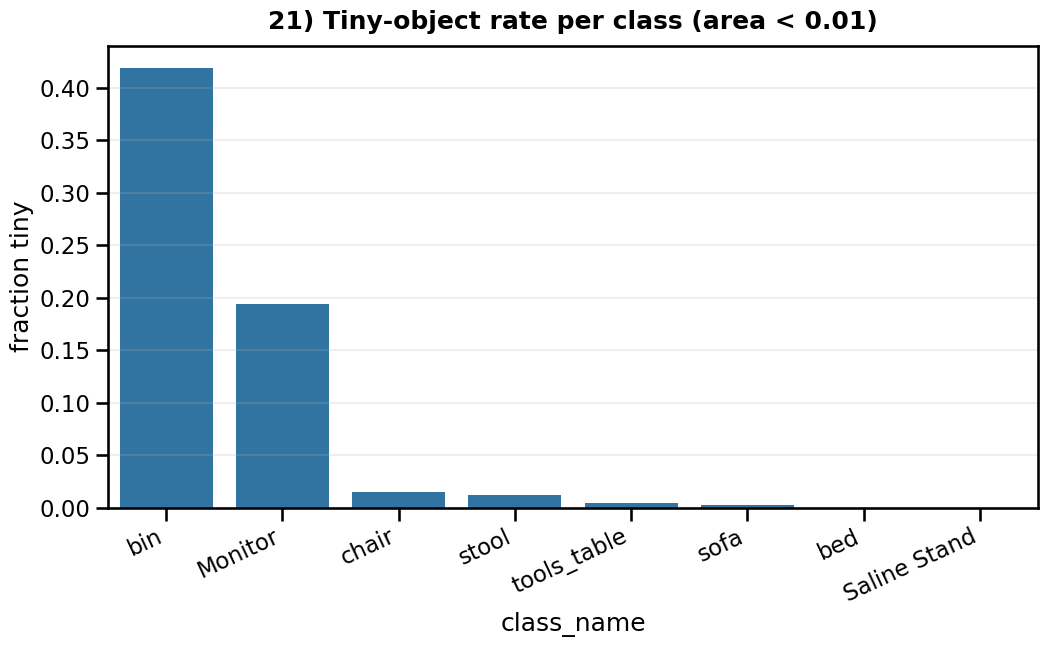

In [73]:
# Tiny threshold: area < 0.01 (tune as needed)
tiny_thr = 0.01
tmp = ann.assign(is_tiny=ann["area"] < tiny_thr).groupby("class_name")["is_tiny"].mean().sort_values(ascending=False)

fig_ok((12,6))
sns.barplot(x=tmp.index, y=tmp.values)
plt.xticks(rotation=25, ha="right")
show_title(f"21) Tiny-object rate per class (area < {tiny_thr})")
plt.ylabel("fraction tiny")
plt.show()

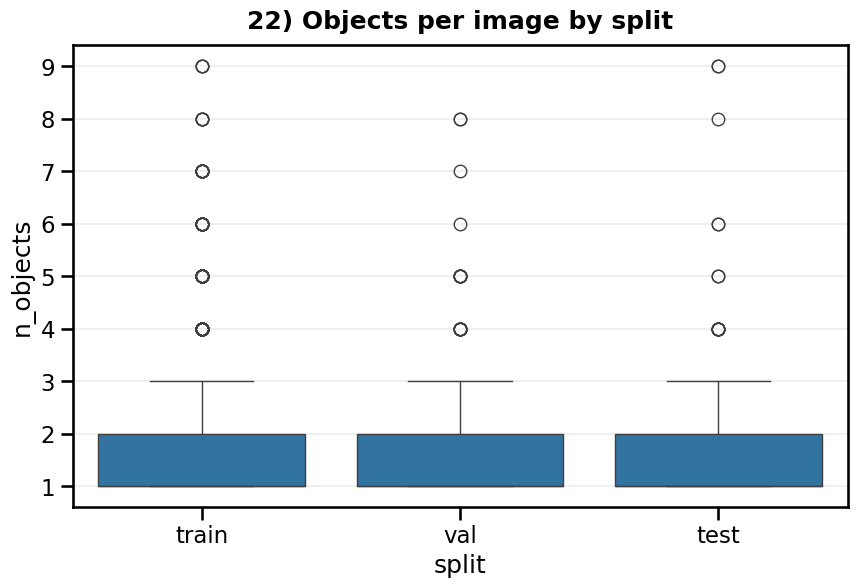

In [74]:
fig_ok((10,6))
sns.boxplot(data=imgs, x="split", y="n_objects")
show_title("22) Objects per image by split")
plt.show()

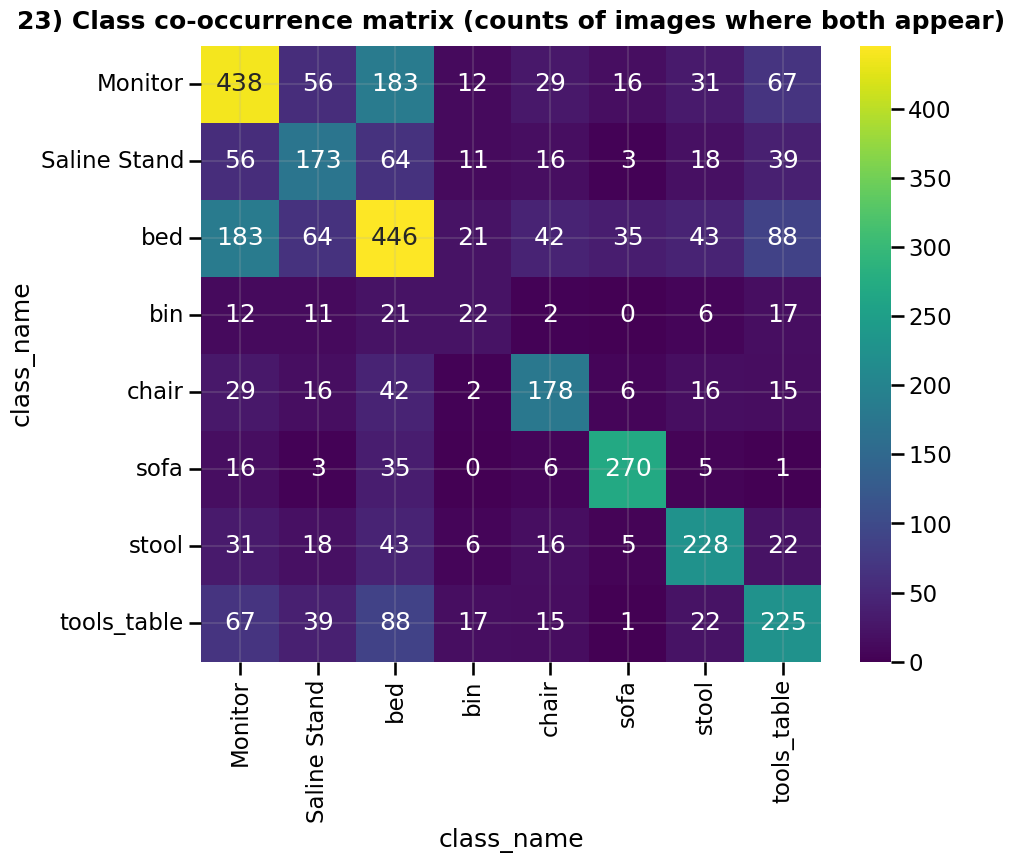

In [75]:
# Build image-level presence matrix
presence = (ann.groupby(["image_path","class_name"]).size()
              .unstack(fill_value=0)
              .astype(bool)
              .astype(int))

# Co-occurrence = dot product of presence vectors
co = presence.T.dot(presence)

fig_ok((10,8))
sns.heatmap(co, annot=True, fmt="d", cmap="viridis")
show_title("23) Class co-occurrence matrix (counts of images where both appear)")
plt.show()

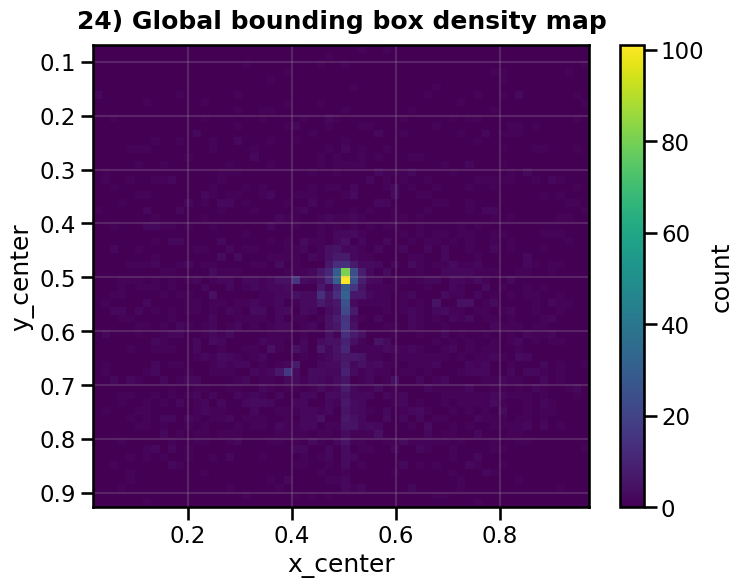

In [76]:
fig_ok((8,6))
plt.hist2d(ann["x_center"], ann["y_center"], bins=60)
plt.colorbar(label="count")
plt.gca().invert_yaxis()
show_title("24) Global bounding box density map")
plt.xlabel("x_center"); plt.ylabel("y_center")
plt.show()

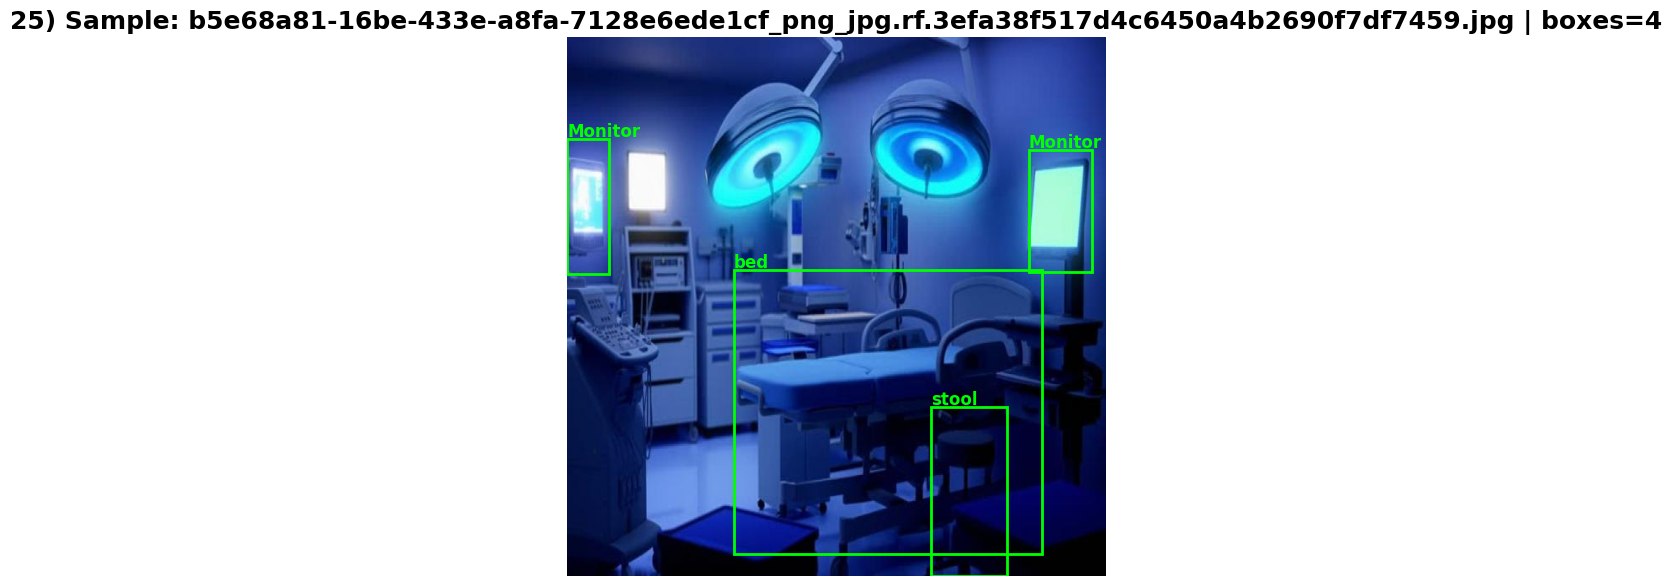

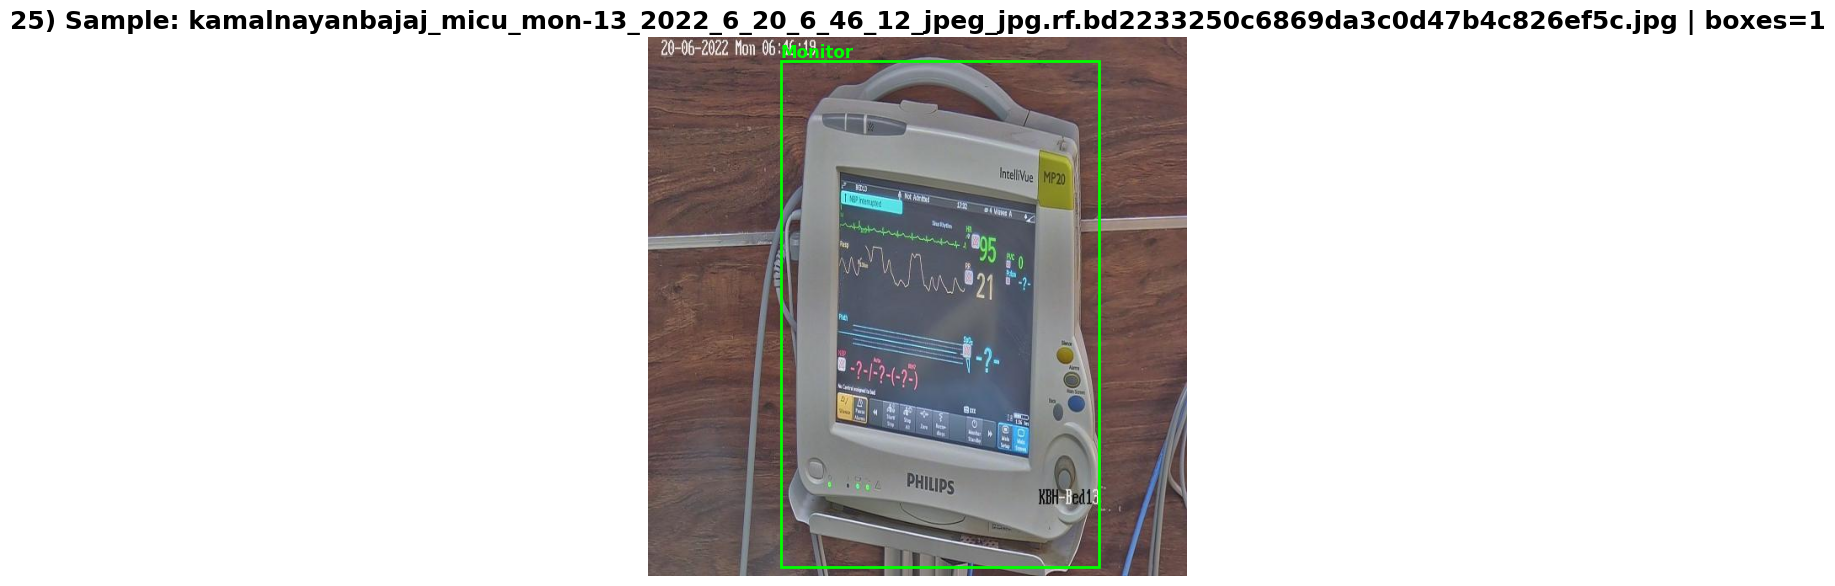

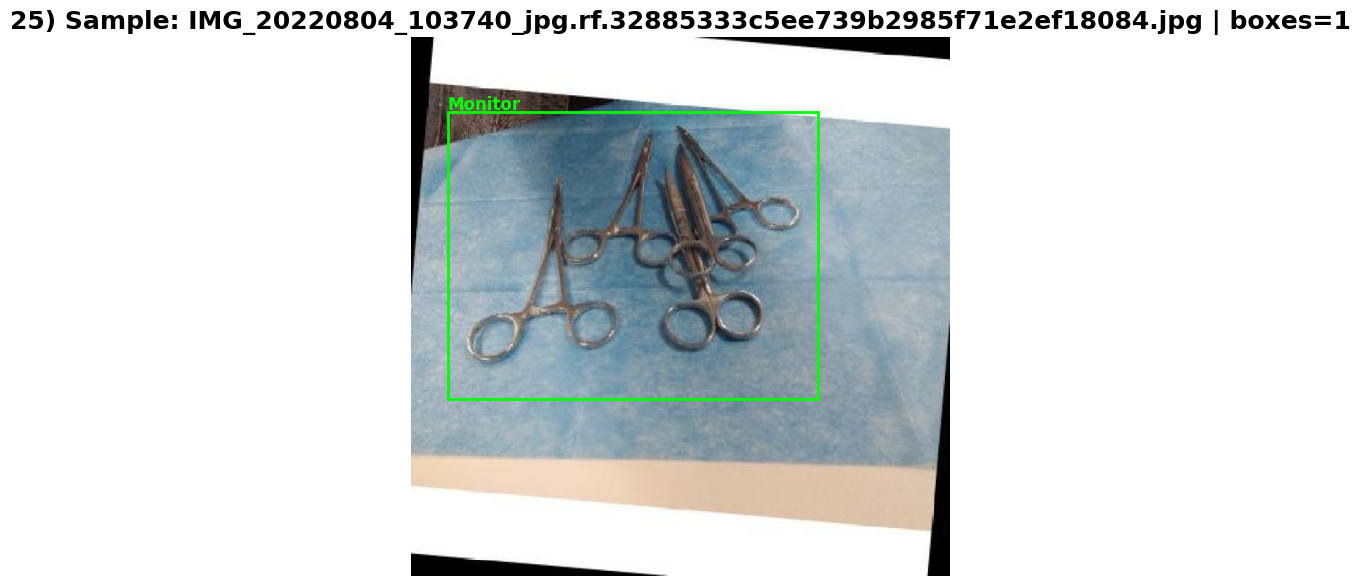

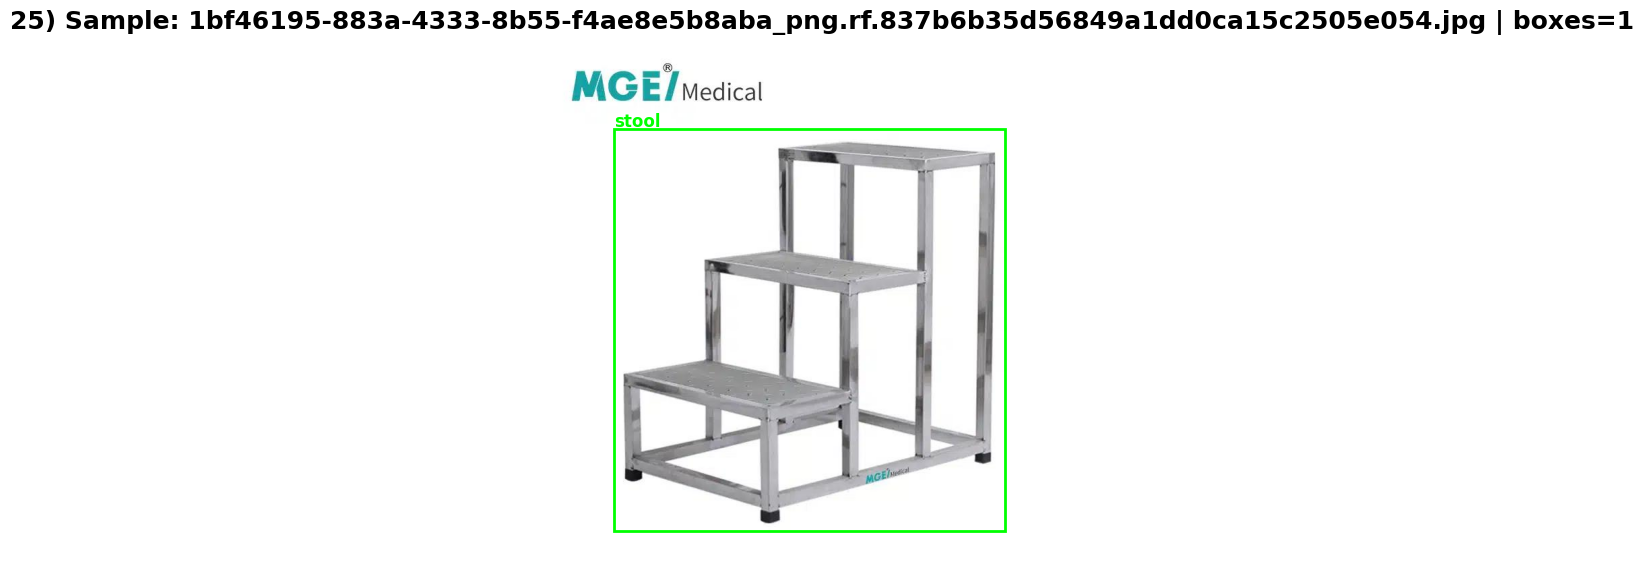

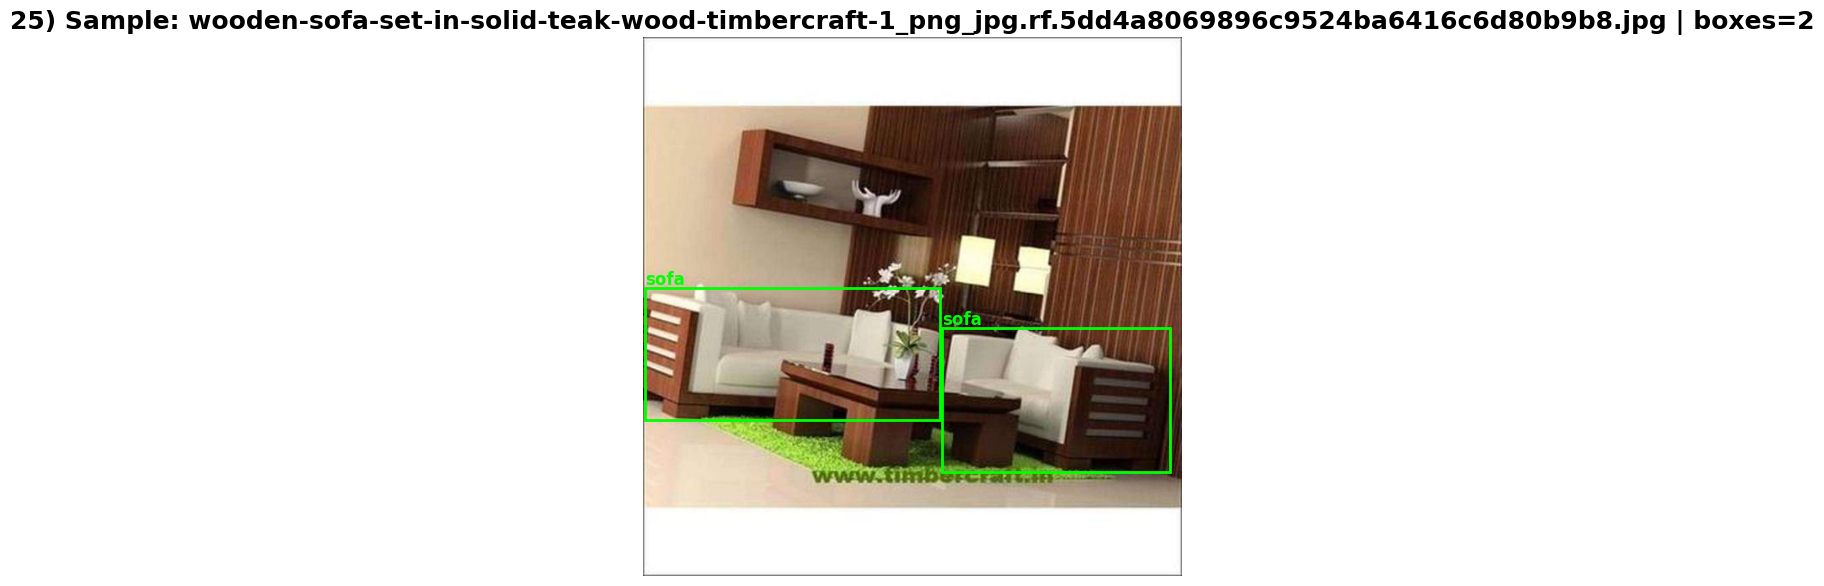

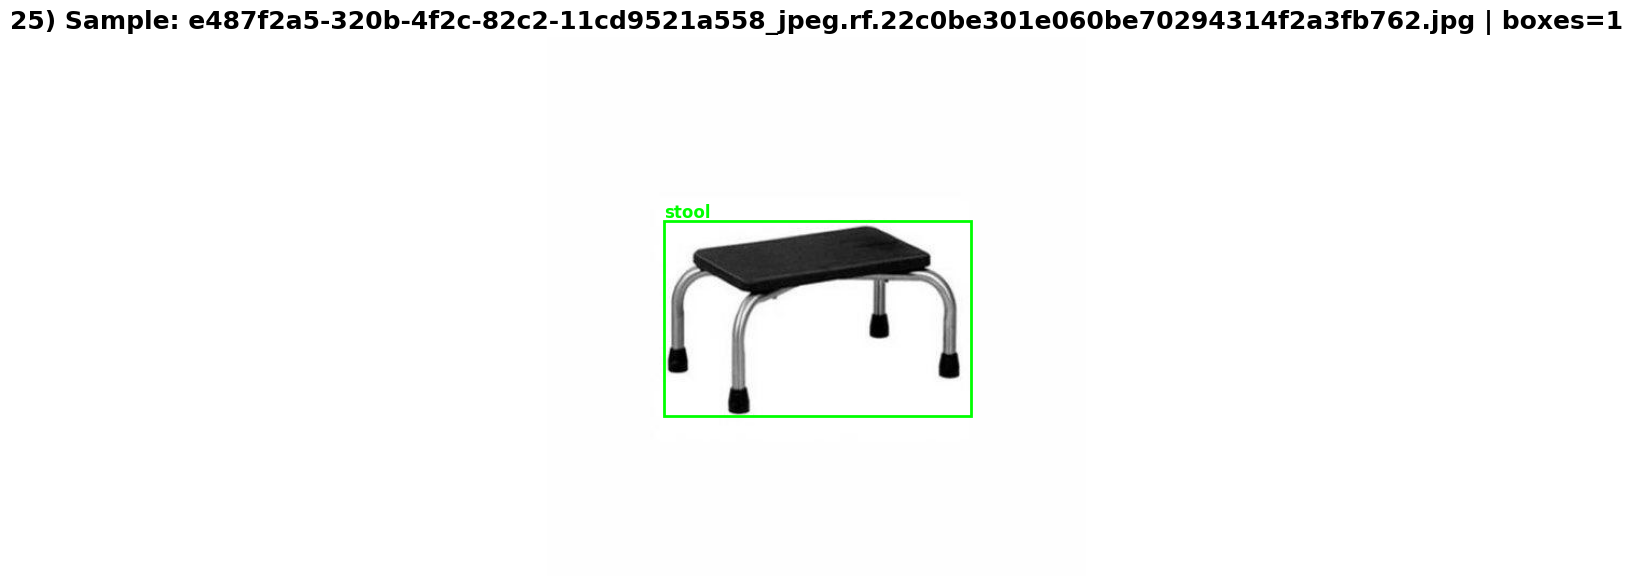

In [77]:
def draw_boxes_on_image(image_path: str, labels_path: str, max_boxes=50):
    im = cv2.imread(image_path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    h, w = im.shape[:2]

    boxes = parse_yolo_label_file(Path(labels_path))
    boxes = boxes[:max_boxes]

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(im)
    ax.axis("off")

    for (cls, xc, yc, bw, bh) in boxes:
        x1 = (xc - bw/2) * w
        y1 = (yc - bh/2) * h
        rect = patches.Rectangle((x1, y1), bw*w, bh*h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-3, names[cls], color="lime", fontsize=12, weight="bold")

    ax.set_title(f"25) Sample: {Path(image_path).name} | boxes={len(boxes)}", fontweight="bold")
    plt.show()

# Show a few random images (across all splits)
sample_imgs = imgs.sample(6, random_state=RANDOM_SEED)
for _, row in sample_imgs.iterrows():
    draw_boxes_on_image(row["image_path"], row["label_path"])

In [78]:
# ============================================
# FINAL CELL — Automatic EDA Findings Summary
# ============================================

from textwrap import fill

def eda_summary(ann, imgs, tiny_threshold=0.01):

    print("="*80)
    print("HOSPITAL OBJECT DETECTION DATASET — EDA SUMMARY REPORT")
    print("="*80)

    total_images = len(imgs)
    total_boxes = len(ann)
    splits = imgs["split"].value_counts()

    print(f"\nTotal Images: {total_images}")
    print(f"Total Annotations (Bounding Boxes): {total_boxes}")
    print("\nSplit Distribution:")
    print(splits.to_string())

    print("\n" + "-"*80)
    print("1) CLASS DISTRIBUTION")
    print("-"*80)

    class_counts = ann["class_name"].value_counts()
    print(class_counts.to_string())

    imbalance_ratio = class_counts.max() / class_counts.min() if len(class_counts) > 1 else 1
    print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}")

    if imbalance_ratio > 5:
        print("Significant class imbalance detected.")
    else:
        print("✓ Class distribution reasonably balanced.")

    print("\n" + "-"*80)
    print("2) OBJECT SIZE ANALYSIS")
    print("-"*80)

    mean_area = ann["area"].mean()
    tiny_fraction = (ann["area"] < tiny_threshold).mean()

    print(f"Average normalized box area: {mean_area:.4f}")
    print(f"Tiny objects (area < {tiny_threshold}): {tiny_fraction*100:.2f}%")

    if tiny_fraction > 0.3:
        print("Large proportion of small objects. Consider larger training resolution.")
    else:
        print("✓ Object sizes mostly moderate/large.")

    print("\n" + "-"*80)
    print("3) OBJECT DENSITY PER IMAGE")
    print("-"*80)

    avg_objects = imgs["n_objects"].mean()
    max_objects = imgs["n_objects"].max()

    print(f"Average objects per image: {avg_objects:.2f}")
    print(f"Maximum objects in single image: {max_objects}")

    if avg_objects > 5:
        print("High scene clutter detected. Occlusion likely.")
    else:
        print("✓ Scene density moderate.")

    print("\n" + "-"*80)
    print("4) SPATIAL BIAS ANALYSIS")
    print("-"*80)

    x_mean = ann["x_center"].mean()
    y_mean = ann["y_center"].mean()

    print(f"Mean X center: {x_mean:.3f}")
    print(f"Mean Y center: {y_mean:.3f}")

    if abs(x_mean - 0.5) < 0.05 and abs(y_mean - 0.5) < 0.05:
        print("Strong central framing bias detected.")
    else:
        print("✓ Object distribution relatively spatially diverse.")

    print("\n" + "-"*80)
    print("5) IMAGE CHARACTERISTICS")
    print("-"*80)

    brightness_mean = imgs["brightness"].mean()
    contrast_mean = imgs["contrast"].mean()

    print(f"Average brightness: {brightness_mean:.2f}")
    print(f"Average contrast: {contrast_mean:.2f}")

    brightness_std = imgs["brightness"].std()

    if brightness_std < 10:
        print("Low lighting variability. Consider brightness augmentation.")
    else:
        print("✓ Lighting conditions reasonably diverse.")

    print("\n" + "="*80)
    print("RECOMMENDED TRAINING STRATEGY")
    print("="*80)

    print("\n• Model: YOLOv8m recommended.")
    
    if tiny_fraction > 0.3:
        print("• Use higher image resolution (e.g., imgsz=960).")
    else:
        print("• Default resolution (imgsz=640) likely sufficient.")

    if imbalance_ratio > 5:
        print("• Monitor per-class recall carefully. Consider class balancing strategies.")
    
    if brightness_std < 10:
        print("• Enable HSV / brightness augmentation.")

    if avg_objects > 5:
        print("• Expect occlusion challenges. Consider multi-scale training.")

    print("\nEDA complete. Interpret results in context of deployment scenario.")
    print("="*80)


# Run the summary
eda_summary(ann, imgs)

HOSPITAL OBJECT DETECTION DATASET — EDA SUMMARY REPORT

Total Images: 1457
Total Annotations (Bounding Boxes): 2411

Split Distribution:
split
train    1039
val       272
test      146

--------------------------------------------------------------------------------
1) CLASS DISTRIBUTION
--------------------------------------------------------------------------------
class_name
Monitor         594
bed             511
sofa            356
tools_table     255
stool           242
Saline Stand    218
chair           204
bin              31

Imbalance Ratio (max/min): 19.16
Significant class imbalance detected.

--------------------------------------------------------------------------------
2) OBJECT SIZE ANALYSIS
--------------------------------------------------------------------------------
Average normalized box area: 0.3023
Tiny objects (area < 0.01): 5.64%
✓ Object sizes mostly moderate/large.

--------------------------------------------------------------------------------
3) OBJECT 

In [ ]:
# ============================================
# FINAL CELL — Generate Markdown EDA Summary
# ============================================

def generate_markdown_summary(ann, imgs, tiny_threshold=0.01, save_path=None):

    total_images = len(imgs)
    total_boxes = len(ann)
    splits = imgs["split"].value_counts()

    class_counts = ann["class_name"].value_counts()
    imbalance_ratio = class_counts.max() / class_counts.min() if len(class_counts) > 1 else 1

    mean_area = ann["area"].mean()
    tiny_fraction = (ann["area"] < tiny_threshold).mean()

    avg_objects = imgs["n_objects"].mean()
    max_objects = imgs["n_objects"].max()

    x_mean = ann["x_center"].mean()
    y_mean = ann["y_center"].mean()

    brightness_mean = imgs["brightness"].mean()
    brightness_std = imgs["brightness"].std()
    contrast_mean = imgs["contrast"].mean()

    # Interpretations
    imbalance_comment = (
        "Significant class imbalance detected. Rare classes may require monitoring or reweighting."
        if imbalance_ratio > 5 else
        "Class distribution is reasonably balanced."
    )

    tiny_comment = (
        "Large proportion of small objects detected. Higher training resolution recommended."
        if tiny_fraction > 0.3 else
        "Object sizes are mostly moderate to large."
    )

    clutter_comment = (
        "High object density per image. Expect occlusion challenges."
        if avg_objects > 5 else
        "Scene density appears moderate."
    )

    spatial_comment = (
        "Strong central framing bias observed."
        if abs(x_mean - 0.5) < 0.05 and abs(y_mean - 0.5) < 0.05 else
        "Object spatial distribution appears reasonably diverse."
    )

    lighting_comment = (
        "Lighting variability is low. Brightness augmentation recommended."
        if brightness_std < 10 else
        "Lighting conditions show reasonable variability."
    )

    resolution_recommendation = (
        "Use higher resolution (e.g., `imgsz=960`)."
        if tiny_fraction > 0.3 else
        "Default resolution (`imgsz=640`) likely sufficient."
    )

    markdown = f"""
# Hospital Object Detection Dataset — EDA Summary

## 1. Dataset Overview

- **Total Images:** {total_images}
- **Total Annotations:** {total_boxes}

### Split Distribution
{splits.to_string()}

---

## 2. Class Distribution

{class_counts.to_string()}

- **Imbalance Ratio (max/min):** {imbalance_ratio:.2f}  
- **Interpretation:** {imbalance_comment}

---

## 3. Object Size Analysis

- **Average Normalized Box Area:** {mean_area:.4f}
- **Tiny Objects (< {tiny_threshold} area):** {tiny_fraction*100:.2f}%  
- **Interpretation:** {tiny_comment}

---

## 4. Scene Complexity

- **Average Objects per Image:** {avg_objects:.2f}
- **Maximum Objects in Single Image:** {max_objects}  
- **Interpretation:** {clutter_comment}

---

## 5. Spatial Distribution

- **Mean X Center:** {x_mean:.3f}
- **Mean Y Center:** {y_mean:.3f}  
- **Interpretation:** {spatial_comment}

---

## 6. Image Characteristics

- **Average Brightness:** {brightness_mean:.2f}
- **Brightness Std Dev:** {brightness_std:.2f}
- **Average Contrast:** {contrast_mean:.2f}  
- **Interpretation:** {lighting_comment}

---

# Recommended Training Strategy

- **Model:** YOLOv8m recommended  
- **Resolution:** {resolution_recommendation}
- **Augmentation:** Enable HSV / brightness augmentation  
- **Monitoring:** Track per-class recall closely  
- **Validation:** Use early stopping and monitor rare classes carefully  

---

## Conclusion

The dataset demonstrates structured hospital scene characteristics with identifiable object classes and moderate scene complexity. Model configuration should account for object size distribution and potential class imbalance to ensure robust detection performance in safety-critical hospital navigation scenarios.
"""

    print(markdown)

    if save_path:
        with open(save_path, "w") as f:
            f.write(markdown)
        print(f"\nMarkdown summary saved to: {save_path}")


# Generate summary (print only)
generate_markdown_summary(ann, imgs)

# Optional: save to file
# generate_markdown_summary(ann, imgs, save_path="EDA_Summary.md")

In [ ]:
import os, glob, zipfile, shutil
from datetime import datetime

# ========= CONFIG =========
# If you've been saving plots, set this to the folder where they live.
# Example: "eda_figures" or "outputs/eda"
EDA_FIG_DIR = "eda_figures"   # change if yours is different
ZIP_NAME = f"eda_graphs_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

KAGGLE_WORKING = "/kaggle/working"  # Kaggle output directory
os.makedirs(KAGGLE_WORKING, exist_ok=True)

# ========= OPTIONAL: SAVE ANY CURRENT OPEN MATPLOTLIB FIGURES =========
# If you have figures open (plt.figure(...) etc.) and didn't save them yet,
# this will save them into EDA_FIG_DIR automatically.
try:
    import matplotlib.pyplot as plt
    os.makedirs(EDA_FIG_DIR, exist_ok=True)

    fig_nums = plt.get_fignums()
    if fig_nums:
        for n in fig_nums:
            fig = plt.figure(n)
            out_path = os.path.join(EDA_FIG_DIR, f"figure_{n}.png")
            fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved {len(fig_nums)} currently-open matplotlib figure(s) into: {EDA_FIG_DIR}")
    else:
        print("No currently-open matplotlib figures detected (that's fine).")
except Exception as e:
    print("Matplotlib not available or no figures to save:", e)

# ========= COLLECT IMAGES =========
# Collect common image formats in the EDA folder (and subfolders).
patterns = ["**/*.png", "**/*.jpg", "**/*.jpeg", "**/*.svg", "**/*.pdf"]
files = []
for p in patterns:
    files.extend(glob.glob(os.path.join(EDA_FIG_DIR, p), recursive=True))

files = sorted(set(files))

if not files:
    raise FileNotFoundError(
        f"No plot files found in '{EDA_FIG_DIR}'.\n"
        "Make sure your EDA plots are saved there (or change EDA_FIG_DIR to the right folder)."
    )

# ========= ZIP THEM =========
zip_path = os.path.join(KAGGLE_WORKING, ZIP_NAME)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for f in files:
        # store relative paths inside the zip (keeps folder structure)
        arcname = os.path.relpath(f, start=EDA_FIG_DIR)
        z.write(f, arcname=os.path.join("eda_graphs", arcname))

print(f"Zipped {len(files)} graph file(s) into:\n{zip_path}")
print("Now go to Kaggle → 'Output' (right panel) → Download the zip.")

In [ ]:
import os
import pandas as pd
from pathlib import Path

DATASET_PATH = Path("/kaggle/input/YOUR_DATASET_FOLDER")  # CHANGE THIS

splits = ["train", "val", "test"]
summary = []

for split in splits:
    image_dir = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"
    
    num_images = len(list(image_dir.glob("*")))
    num_labels = sum(len(open(f).read().strip().split("\n")) 
                     for f in label_dir.glob("*.txt") 
                     if f.stat().st_size > 0)
    
    summary.append([split, num_images, num_labels])

df_dataset = pd.DataFrame(summary, columns=["Split", "Images", "Annotations"])
df_dataset["Image %"] = (df_dataset["Images"] / df_dataset["Images"].sum()) * 100

df_dataset

In [ ]:
import yaml
from collections import Counter

# Load class names
with open("/kaggle/input/datasets/georgelukaanya/hospitaldata/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]

class_counts = Counter()

for split in splits:
    label_dir = DATASET_PATH / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        if label_file.stat().st_size == 0:
            continue
        
        with open(label_file, "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_names[class_id]] += 1

df_classes = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
).sort_values(by="Count", ascending=False)

df_classes["Percentage (%)"] = (df_classes["Count"] / df_classes["Count"].sum()) * 100

df_classes

In [ ]:
import numpy as np

box_areas = []

for split in splits:
    label_dir = DATASET_PATH / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        if label_file.stat().st_size == 0:
            continue
        
        with open(label_file, "r") as f:
            for line in f:
                parts = line.split()
                w = float(parts[3])
                h = float(parts[4])
                area = w * h
                box_areas.append(area)

box_areas = np.array(box_areas)

df_box_stats = pd.DataFrame({
    "Metric": [
        "Mean Area",
        "Median Area",
        "Min Area",
        "Max Area",
        "Tiny Objects (<0.01)"
    ],
    "Value": [
        box_areas.mean(),
        np.median(box_areas),
        box_areas.min(),
        box_areas.max(),
        (box_areas < 0.01).mean() * 100
    ]
})

df_box_stats

In [ ]:
objects_per_image = []

for split in splits:
    label_dir = DATASET_PATH / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        if label_file.stat().st_size == 0:
            objects_per_image.append(0)
        else:
            with open(label_file, "r") as f:
                objects_per_image.append(len(f.readlines()))

objects_per_image = np.array(objects_per_image)

df_scene = pd.DataFrame({
    "Metric": [
        "Mean Objects/Image",
        "Median Objects/Image",
        "Max Objects/Image",
        "Min Objects/Image"
    ],
    "Value": [
        objects_per_image.mean(),
        np.median(objects_per_image),
        objects_per_image.max(),
        objects_per_image.min()
    ]
})

df_scenex_centers = []
y_centers = []

for split in splits:
    label_dir = DATASET_PATH / split / "labels"
    
    for label_file in label_dir.glob("*.txt"):
        if label_file.stat().st_size == 0:
            continue
        
        with open(label_file, "r") as f:
            for line in f:
                parts = line.split()
                x_centers.append(float(parts[1]))
                y_centers.append(float(parts[2]))

x_centers = np.array(x_centers)
y_centers = np.array(y_centers)

df_spatial = pd.DataFrame({
    "Metric": [
        "Mean X Center",
        "Std X Center",
        "Mean Y Center",
        "Std Y Center"
    ],
    "Value": [
        x_centers.mean(),
        x_centers.std(),
        y_centers.mean(),
        y_centers.std()
    ]
})

df_spatial

In [ ]:
df_master = pd.DataFrame({
    "Category": [
        "Dataset", "Dataset",
        "Class Imbalance",
        "Object Size",
        "Scene Complexity"
    ],
    "Metric": [
        "Total Images",
        "Total Annotations",
        "Imbalance Ratio (Max/Min)",
        "Tiny Objects %",
        "Mean Objects/Image"
    ],
    "Value": [
        df_dataset["Images"].sum(),
        df_dataset["Annotations"].sum(),
        df_classes["Count"].max() / df_classes["Count"].min(),
        (box_areas < 0.01).mean() * 100,
        objects_per_image.mean()
    ]
})

df_master

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
from collections import Counter

# =========================
# 1) AUTO-FIND data.yaml
# =========================
KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")
KAGGLE_WORKING.mkdir(parents=True, exist_ok=True)

def find_data_yaml(search_root: Path) -> Path:
    for root, dirs, files in os.walk(search_root):
        if "data.yaml" in files:
            return Path(root) / "data.yaml"
    return None

data_yaml_path = find_data_yaml(KAGGLE_INPUT)
if data_yaml_path is None:
    raise FileNotFoundError(
        "Could not find data.yaml anywhere under /kaggle/input.\n"
        "Make sure your dataset was added to the notebook and contains data.yaml."
    )

DATASET_PATH = data_yaml_path.parent
print(f"Found data.yaml at: {data_yaml_path}")
print(f"Using dataset root: {DATASET_PATH}")

# =========================
# 2) LOAD CLASS NAMES
# =========================
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml.get("names", None)
if not class_names:
    raise ValueError("data.yaml does not contain 'names' (class list).")

splits = ["train", "val", "test"]

# =========================
# 3) HELPER: FIND split dirs
# =========================
def resolve_split_dir(split_key: str) -> Path:
    """
    data.yaml may contain train/val/test paths (like ../train/images).
    We'll try to resolve them; otherwise fallback to DATASET_PATH/split.
    """
    v = data_yaml.get(split_key, None)
    if isinstance(v, str):
        p = (data_yaml_path.parent / v).resolve()
        # if it points to images folder, go up one to split folder
        if p.name == "images":
            return p.parent
        # if it's already split folder
        return p
    # fallback
    return (DATASET_PATH / split_key).resolve()

split_dirs = {s: resolve_split_dir(s) for s in splits}

# =========================
# 4) TABULAR EDA TABLES
# =========================

# ---- A) Split summary (images + annotations) ----
split_summary = []
for split in splits:
    split_dir = split_dirs[split]
    image_dir = split_dir / "images"
    label_dir = split_dir / "labels"

    num_images = len([p for p in image_dir.glob("*") if p.is_file()]) if image_dir.exists() else 0

    num_labels = 0
    if label_dir.exists():
        for lf in label_dir.glob("*.txt"):
            if lf.stat().st_size == 0:
                continue
            with open(lf, "r") as f:
                num_labels += sum(1 for line in f if line.strip())

    split_summary.append([split, str(split_dir), num_images, num_labels])

df_split = pd.DataFrame(split_summary, columns=["Split", "SplitPath", "Images", "Annotations"])
total_images = df_split["Images"].sum()
df_split["Image %"] = (df_split["Images"] / total_images * 100) if total_images else 0

# ---- B) Class distribution ----
class_counts = Counter()

# Also collect boxes for other tables in one pass
box_areas = []
objects_per_image = []
x_centers, y_centers = [], []

for split in splits:
    split_dir = split_dirs[split]
    label_dir = split_dir / "labels"

    if not label_dir.exists():
        continue

    for lf in label_dir.glob("*.txt"):
        if lf.stat().st_size == 0:
            objects_per_image.append(0)
            continue

        n_objs = 0
        with open(lf, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 5:
                    continue

                cls = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])

                # class count
                if 0 <= cls < len(class_names):
                    class_counts[class_names[cls]] += 1
                else:
                    class_counts[f"class_{cls}"] += 1

                # box stats
                box_areas.append(w * h)
                x_centers.append(x)
                y_centers.append(y)

                n_objs += 1

        objects_per_image.append(n_objs)

df_classes = pd.DataFrame(class_counts.items(), columns=["Class", "Count"]).sort_values("Count", ascending=False)
total_ann = int(df_classes["Count"].sum()) if not df_classes.empty else 0
df_classes["Percentage (%)"] = (df_classes["Count"] / total_ann * 100) if total_ann else 0

# ---- C) Box size stats ----
box_areas = np.array(box_areas, dtype=float) if box_areas else np.array([], dtype=float)

df_box_stats = pd.DataFrame({
    "Metric": ["Mean Area", "Median Area", "Min Area", "Max Area", "Tiny Objects % (<0.01)"],
    "Value": [
        float(box_areas.mean()) if box_areas.size else np.nan,
        float(np.median(box_areas)) if box_areas.size else np.nan,
        float(box_areas.min()) if box_areas.size else np.nan,
        float(box_areas.max()) if box_areas.size else np.nan,
        float((box_areas < 0.01).mean() * 100) if box_areas.size else np.nan
    ]
})

# ---- D) Scene complexity ----
objects_per_image = np.array(objects_per_image, dtype=float) if objects_per_image else np.array([], dtype=float)

df_scene = pd.DataFrame({
    "Metric": ["Mean Objects/Image", "Median Objects/Image", "Max Objects/Image", "Min Objects/Image"],
    "Value": [
        float(objects_per_image.mean()) if objects_per_image.size else np.nan,
        float(np.median(objects_per_image)) if objects_per_image.size else np.nan,
        float(objects_per_image.max()) if objects_per_image.size else np.nan,
        float(objects_per_image.min()) if objects_per_image.size else np.nan
    ]
})

# ---- E) Spatial distribution ----
x_centers = np.array(x_centers, dtype=float) if x_centers else np.array([], dtype=float)
y_centers = np.array(y_centers, dtype=float) if y_centers else np.array([], dtype=float)

df_spatial = pd.DataFrame({
    "Metric": ["Mean X Center", "Std X Center", "Mean Y Center", "Std Y Center"],
    "Value": [
        float(x_centers.mean()) if x_centers.size else np.nan,
        float(x_centers.std()) if x_centers.size else np.nan,
        float(y_centers.mean()) if y_centers.size else np.nan,
        float(y_centers.std()) if y_centers.size else np.nan
    ]
})

# ---- F) Master summary ----
imbalance_ratio = (df_classes["Count"].max() / df_classes["Count"].min()) if (not df_classes.empty and df_classes["Count"].min() > 0) else np.nan

df_master = pd.DataFrame({
    "Category": ["Dataset", "Dataset", "Class Imbalance", "Object Size", "Scene Complexity"],
    "Metric": ["Total Images", "Total Annotations", "Imbalance Ratio (Max/Min)", "Tiny Objects %", "Mean Objects/Image"],
    "Value": [
        int(total_images),
        int(total_ann),
        float(imbalance_ratio) if not pd.isna(imbalance_ratio) else np.nan,
        float((box_areas < 0.01).mean() * 100) if box_areas.size else np.nan,
        float(objects_per_image.mean()) if objects_per_image.size else np.nan
    ]
})

# =========================
# 5) EXPORT EXCEL
# =========================
out_path = KAGGLE_WORKING / "eda_tables.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    df_master.to_excel(writer, sheet_name="EDA_Summary", index=False)
    df_split.to_excel(writer, sheet_name="Split_Summary", index=False)
    df_classes.to_excel(writer, sheet_name="Class_Distribution", index=False)
    df_box_stats.to_excel(writer, sheet_name="Box_Size_Stats", index=False)
    df_scene.to_excel(writer, sheet_name="Scene_Complexity", index=False)
    df_spatial.to_excel(writer, sheet_name="Spatial_Distribution", index=False)

print(f"\nSaved combined Excel file to: {out_path}")
print("Kaggle: right panel → Output → eda_tables.xlsx → Download")